In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer ,CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD


In [2]:
# Load the review dataset
df = pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Books_Cleaned.csv")

In [3]:
# Check the first few rows to understand its structure
df.head()

,book_id,title,author,Year-Of-Publication,publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


### 1. Data Preprocessing & Feature Engineering

#### a) Check for Missing Data

In [4]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()
print(missing_values)

book_id                0
title                  0
author                 0
Year-Of-Publication    0
publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64


#### b) Data Types and Basic Info

In [5]:
# Check data types and basic info about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   book_id              271360 non-null  object
 1   title                271360 non-null  object
 2   author               271360 non-null  object
 3   Year-Of-Publication  271360 non-null  int64 
 4   publisher            271360 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271360 non-null  object
dtypes: int64(1), object(7)
memory usage: 16.6+ MB
None


#### c) Clean and Normalize the Text

In [6]:
# Function to clean text
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove special characters
    return text

# Apply cleaning to each relevant field
df['title'] = df['title'].apply(clean_text)
df['author'] = df['author'].apply(clean_text)
df['publisher'] = df['publisher'].apply(clean_text)

# Check the cleaned data
df[['title', 'author', "publisher"]].head()


,title,author,publisher
0,classical mythology,mark p o morford,oxford university press
1,clara callan,richard bruce wright,harperflamingo canada
2,decision in normandy,carlo deste,harperperennial
3,flu the story of the great influenza pandemic ...,gina bari kolata,farrar straus giroux
4,the mummies of urumchi,e j w barber,w w norton amp company


In [7]:
df.isnull().sum()

book_id                0
title                  0
author                 0
Year-Of-Publication    0
publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64

#### d) Combine All Features into a Single “Soup” of Text

In [8]:
# Combine all cleaned metadata features into a single "soup" of text
df['combined'] = df['title'] + ' ' + df['author'] + ' ' + df['publisher'] 

# Check the combined text column
print(df['combined'].head())


0    classical mythology mark p o morford oxford un...
1    clara callan richard bruce wright harperflamin...
2     decision in normandy carlo deste harperperennial
3    flu the story of the great influenza pandemic ...
4    the mummies of urumchi e j w barber w w norton...
Name: combined, dtype: object


In [9]:
df.head()

,book_id,title,author,Year-Of-Publication,publisher,Image-URL-S,Image-URL-M,Image-URL-L,combined
0,0195153448,classical mythology,mark p o morford,2002,oxford university press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,classical mythology mark p o morford oxford un...
1,0002005018,clara callan,richard bruce wright,2001,harperflamingo canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,clara callan richard bruce wright harperflamin...
2,0060973129,decision in normandy,carlo deste,1991,harperperennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,decision in normandy carlo deste harperperennial
3,0374157065,flu the story of the great influenza pandemic ...,gina bari kolata,1999,farrar straus giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,flu the story of the great influenza pandemic ...
4,0393045218,the mummies of urumchi,e j w barber,1999,w w norton amp company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,the mummies of urumchi e j w barber w w norton...


In [10]:
# Verify after cleaning
print(f"Data after cleaning: {df.shape}")


Data after cleaning: (271360, 9)


In [11]:
# For demonstration, we're using only the first 30 rows of the full dataset
df_subset = df.head(30)
df_subset.head()

,book_id,title,author,Year-Of-Publication,publisher,Image-URL-S,Image-URL-M,Image-URL-L,combined
0,0195153448,classical mythology,mark p o morford,2002,oxford university press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,classical mythology mark p o morford oxford un...
1,0002005018,clara callan,richard bruce wright,2001,harperflamingo canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,clara callan richard bruce wright harperflamin...
2,0060973129,decision in normandy,carlo deste,1991,harperperennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,decision in normandy carlo deste harperperennial
3,0374157065,flu the story of the great influenza pandemic ...,gina bari kolata,1999,farrar straus giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,flu the story of the great influenza pandemic ...
4,0393045218,the mummies of urumchi,e j w barber,1999,w w norton amp company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,the mummies of urumchi e j w barber w w norton...


### 2. Text Vectorization

#### a) TF-IDF Vectorizer

In [12]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

In [13]:
# Fit and transform the combined metadata
tfidf_matrix = vectorizer.fit_transform(df_subset['combined'])

In [14]:
# Print feature dimensions
print(f"Feature dimensions: {tfidf_matrix.shape}")

Feature dimensions: (30, 213)


#### b) CountVectorizer

In [15]:
# Initialize CountVectorizer
count_vectorizer = CountVectorizer(stop_words='english')

In [16]:
# Fit and transform the combined metadata
count_matrix = count_vectorizer.fit_transform(df_subset['combined'])

In [17]:
# Print feature dimensions
print(f"Feature dimensions: {count_matrix.shape}")

Feature dimensions: (30, 213)


### 3. Build the Similarity Matrix

#### a) Compute Pairwise Cosine Similarity

In [18]:
# Compute Cosine Similarity
similarity_matrix = cosine_similarity(tfidf_matrix)

In [19]:
#Store the Similarity Matrix for later querying
similarity_df = pd.DataFrame(similarity_matrix, index=df_subset['title'], columns=df_subset['title'])

#### b) Visualize Similarity Scores

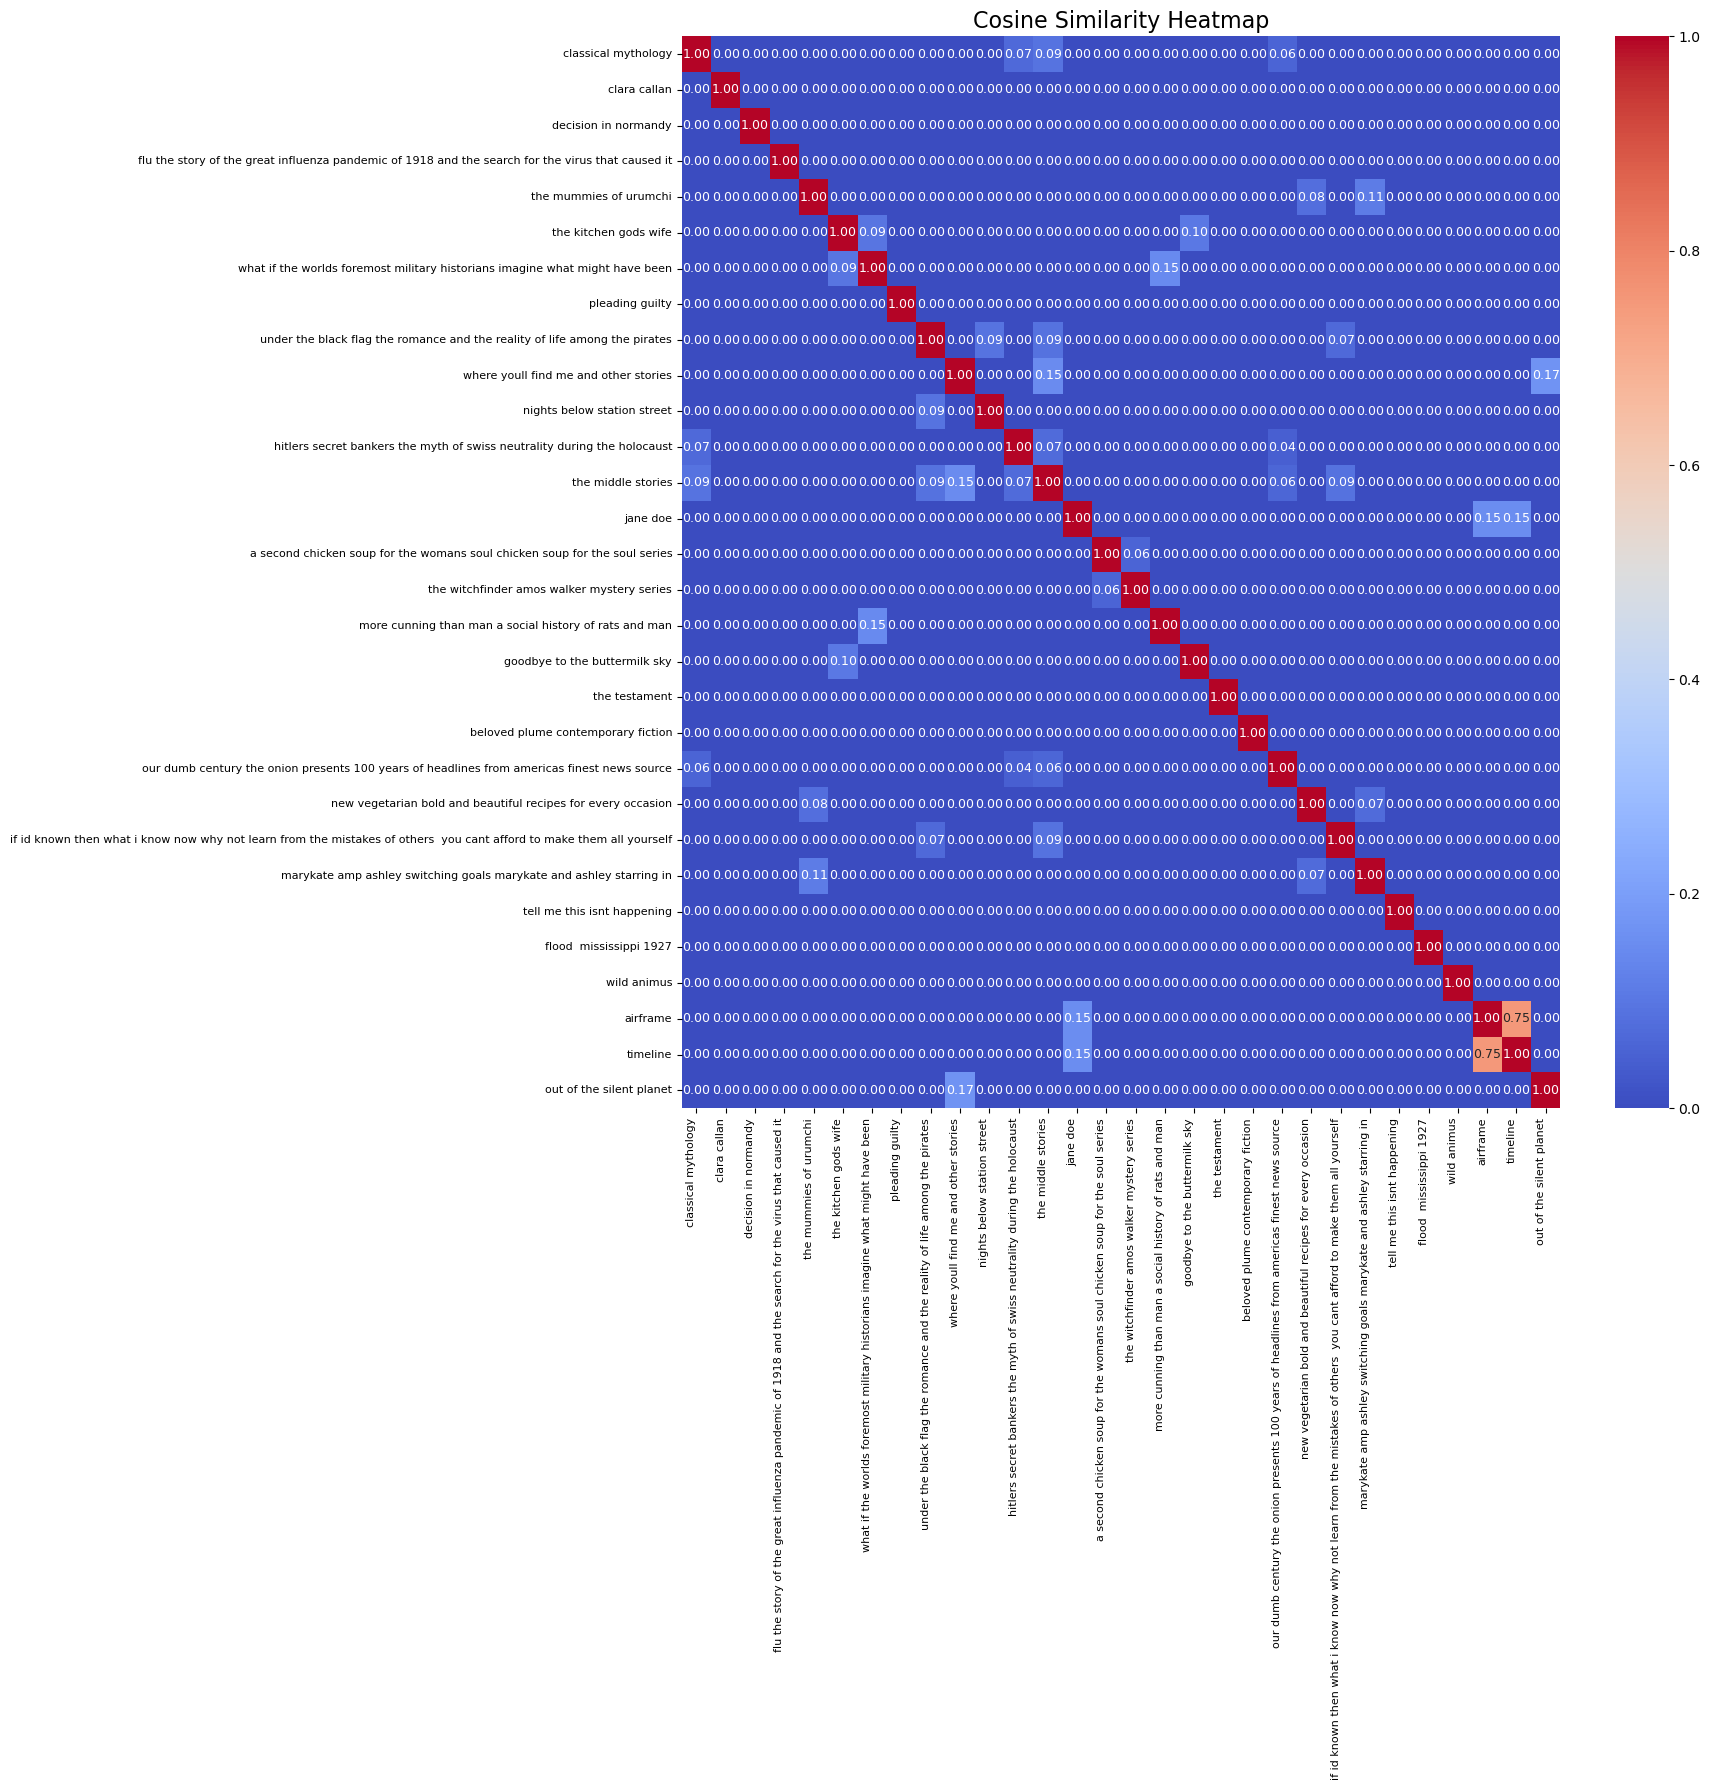

In [20]:
# Visualize the Similarity Matrix using a Heatmap
def plot_similarity_heatmap(similarity_matrix, book_titles):
    plt.figure(figsize=(18, 18))  
    sns.heatmap(similarity_matrix, 
                annot=True, 
                cmap='coolwarm', 
                xticklabels=book_titles, 
                yticklabels=book_titles, 
                fmt='.2f', 
                annot_kws={"size":9})
    
    plt.xticks(rotation=90, ha='right', fontsize=8)  
    plt.yticks(fontsize=8)  
    plt.title("Cosine Similarity Heatmap", fontsize=16)
    plt.tight_layout() 
    plt.show()

# Plot the heatmap
plot_similarity_heatmap(similarity_matrix, df_subset['title'].tolist())


### 4. Generate Book Recommendations

In [21]:
#Display top-k most similar books for each book
def get_top_k_similar_books(similarity_matrix, book_titles, top_k=3):
    for i, book_title in enumerate(book_titles):
        # Get the sorted indices of the most similar books
        similar_books_indices = similarity_matrix[i].argsort()[-top_k-1:-1][::-1]
        similar_books = [book_titles[j] for j in similar_books_indices]
        print(f"Book: {book_title}")
        print(f"Top {top_k} similar books: {', '.join(similar_books)}\n")

# Get top 3 similar books for each book
get_top_k_similar_books(similarity_matrix, df_subset['title'].tolist(), top_k=3)

Book: classical mythology
Top 3 similar books: the middle stories, hitlers secret bankers the myth of swiss neutrality during the holocaust, our dumb century the onion presents 100 years of headlines from americas finest news source

Book: clara callan
Top 3 similar books: out of the silent planet, timeline, decision in normandy

Book: decision in normandy
Top 3 similar books: out of the silent planet, timeline, clara callan

Book: flu the story of the great influenza pandemic of 1918 and the search for the virus that caused it
Top 3 similar books: out of the silent planet, timeline, clara callan

Book: the mummies of urumchi
Top 3 similar books: marykate amp ashley switching goals marykate and ashley starring in, new vegetarian bold and beautiful recipes for every occasion, out of the silent planet

Book: the kitchen gods wife
Top 3 similar books: goodbye to the buttermilk sky, what if the worlds foremost military historians imagine what might have been, out of the silent planet

Book